In [1]:
import os
import path_file
os.chdir(os.path.dirname(os.path.dirname(path_file.__file__)))
os.getcwd()

'c:\\Users\\julia\\Desktop\\gasification'

In [2]:
import sys
import cantera as ct
import numpy as np
import scipy.optimize as opt
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.legend_handler import HandlerTuple
from openpyxl import load_workbook
import os
from openpyxl import Workbook

import phases
import feedstock as fs
import fuel as fu
import energy as en
import gasifier as gs

c:\Users\julia\Desktop\gasification\phases.py:24: UserWarning: NasaPoly2::validate: 
For species Fe(c), discontinuity in cp/R detected at Tmid = 1000.0
	Value computed using low-temperature polynomial:  0.0
	Value computed using high-temperature polynomial: 4.2881898

  solid = ct.Solution('data/min-species.xml','solid')
c:\Users\julia\Desktop\gasification\phases.py:24: UserWarning: NasaPoly2::validate: 
For species Fe(c), discontinuity in h/RT detected at Tmid = 1000.0
	Value computed using low-temperature polynomial:  0.0
	Value computed using high-temperature polynomial: 3.425820683333331

  solid = ct.Solution('data/min-species.xml','solid')
c:\Users\julia\Desktop\gasification\phases.py:24: UserWarning: NasaPoly2::validate: 
For species Fe(c), discontinuity in s/R detected at Tmid = 1000.0
	Value computed using low-temperature polynomial:  0.0
	Value computed using high-temperature polynomial: 8.486560101557188

  solid = ct.Solution('data/min-species.xml','solid')
c:\Users\julia\D

In [ ]:
df = pd.read_excel('notebooks/ascher_2022_modificado.xlsx', 'Raw Data',header=0)

pd.set_option('display.max_rows', None)

df_filtrado = df[df.iloc[:, 23] == 'air'].copy()

df_saida = pd.DataFrame({
    'type': df_filtrado.iloc[:, 1].values,
    'lhv': df_filtrado.iloc[:, 4].values,
    'ua_C': df_filtrado.iloc[:, 5].values,
    'ua_H': df_filtrado.iloc[:, 6].values,
    'ua_N': df_filtrado.iloc[:, 7].values,
    'ua_S': df_filtrado.iloc[:, 8].values,
    'ua_O': df_filtrado.iloc[:, 9].values,
    'ash': df_filtrado.iloc[:, 10].values,
    'moisture': df_filtrado.iloc[:, 11].values,
    'T_exp': df_filtrado.iloc[:, 17].values +273.15,
    'ER': df_filtrado.iloc[:, 22].values,
    'N2': df_filtrado.iloc[:, 28].values,
    'H2': df_filtrado.iloc[:, 29].values,
    'CO': df_filtrado.iloc[:, 30].values,
    'CO2': df_filtrado.iloc[:, 31].values,
    'CH4': df_filtrado.iloc[:, 32].values,
    'lhv_gas': df_filtrado.iloc[:, 34].values,
    'yield': df_filtrado.iloc[:, 36].values
})

print(df_saida.to_string(index=False))

                                               type       lhv      ua_C      ua_H     ua_N     ua_S      ua_O       ash  moisture   T_exp     ER        N2        H2        CO       CO2       CH4  lhv_gas     yield
                               solid recovered fuel 19.450000 59.392197  8.572777 0.932718 0.274329 32.302223 20.694800      6.40 1122.25  0.256 61.770000  8.480000  9.740000 13.360000  4.180000 5.390000      1.62
                               solid recovered fuel 19.450000 59.392197  8.572777 0.932718 0.274329 32.302223 20.694800      6.40 1125.25  0.255 60.640000  7.110000  8.980000 15.690000  4.200000 5.652000      1.73
                               solid recovered fuel 19.450000 59.392197  8.572777 0.932718 0.274329 32.302223 20.694800      6.40 1142.25  0.272 61.670000  8.440000 10.470000 12.280000  4.570000 5.550000      1.72
                               solid recovered fuel 19.450000 59.392197  8.572777 0.932718 0.274329 32.302223 20.694800      6.40 1152.25  0.302

In [13]:
heat_test = 0
methane_test = 0
char_test = 0
j = 0
hydro_si = []
def gasification (heat_test,methane_test,char_test, j):
    T0 = 298.15
    P0 = ct.one_atm
    
    outs_by_ER1= []
    
    moist_WB = df_saida.loc[j, 'moisture']/100
    LHV_WB = df_saida.loc[j, 'lhv']
    moist = moist_WB / (1 - moist_WB) #db
    LHV = LHV_WB / (1 - moist_WB) # db

    #rice husk
    fuel1 = fs.create_fuel_stream(1, 
                                [df_saida.loc[j, 'ua_C'],df_saida.loc[j, 'ua_H'], df_saida.loc[j, 'ua_O'], 
                                 df_saida.loc[j, 'ua_N'], df_saida.loc[j, 'ua_S'], 0], #ultimate db
                                df_saida.loc[j, 'ash'] / 100 , #ash db
                                moist, #moist db
                                HHV=None,#HHV MJ/kg, d.b..
                                LHV = LHV
                                #ashComposition=[5.67, 25.58, 2.21, 0.27, 0, 30.39, 17.17, 12.70, 0, 6.01, 0]
                                ) 
    #print(moist)
    #print(LHV)
    #print(fuel1.get_mass())
    fuel1.set_HHV_from_LHV(LHV)
    #print(fuel1.fuelHHV)

    air1 = fs.create_air_from_ER(fuel1, df_saida.loc[j, 'ER'])
    outlet = gs.gasify_nonisot(fuel1, air1, T0=T0, P=P0, heatLossFraction =heat_test, charFormation=char_test, directMethaneConv =methane_test)
        
    outT = outlet.T 
    outH2 =  100*outlet.get_syngas_fraction('H2', water=False, nitrogen=True) 
    outCO =  100*outlet.get_syngas_fraction('CO', water=False, nitrogen=True)
    outCO2 =  100*outlet.get_syngas_fraction('CO2', water=False, nitrogen=True) 
    outN2 =  100*outlet.get_syngas_fraction('N2', water=False, nitrogen=True) 
    outCH4 =  100*outlet.get_syngas_fraction('CH4', water=False, nitrogen=True) 
    outyield = outlet.get_syngas_amount(basis='vol', water=True, nitrogen=True)
    mape_h2 = (100)*(np.abs((df_saida.loc[j, 'H2']- outH2)/outH2))
    mape_co2 = (100)*(np.abs((df_saida.loc[j, 'CO2'] - outCO2)/ outCO2) )
    mape_n2 = (100)*(np.abs((df_saida.loc[j, 'N2'] - outN2)/outN2) )
    mape_co = (100)*(np.abs((df_saida.loc[j, 'CO']- outCO)/ outCO) )
    mape_ch4 = (100)*(np.abs((df_saida.loc[j, 'CH4'] - outCH4)/ outCH4) )
    mape_yield = (100)*(np.abs((df_saida.loc[j, 'yield'] - outyield)/ outyield))
    #max_methane_conv = (fuel1.species_moles[phases.indices['H']]/4)/fuel1.species_moles[phases.indices['C(gr)']]
    #print("Max_CH4:", max_methane_conv)
    mape_T = (100)*(np.abs((df_saida.loc[j, 'T_exp'] - outT)/outT))
    
    return  mape_T, mape_h2, mape_co, mape_co2, mape_n2, mape_yield, mape_ch4, outT, outH2, outCO, outCO2, outN2, outCH4, outyield

In [15]:
gasification (heat_test,methane_test,char_test, j)

(9.926771268650892,
 70.14165592035138,
 62.51356974572766,
 192.6758545385231,
 53.58875189021567,
 38.26184108097789,
 1221.1103984910276,
 1020.9069065235478,
 28.40077124631954,
 25.982735443020555,
 4.564776968385517,
 40.21778889391121,
 0.3164005070866444,
 2.6239849525232)

In [ ]:
def objective_function(x, j):
    heat_test, methane_test, char_test = x
    mape_T, mape_h2, mape_co, mape_co2, mape_n2, mape_yield, mape_ch4, outT, outH2, outCO, outCO2, outN2, outCH4, outyield = gasification(heat_test, methane_test, char_test, j)
    total_error = max(mape_h2, mape_T, mape_co, mape_co2, mape_n2, mape_ch4)
    return total_error

results = []
bounds = [(0, 0.30), (0, 0.25), (0, 0.20)]
x0 = [0.139, 0.152, 0.05]

all_results = []

for j in range(len(df_saida)):
    try:
        result = minimize(objective_function, x0, bounds=bounds, args=(j,))
        heat_test_opt, methane_test_opt, char_test_opt = result.x
        mape_T_opt, mape_h2_opt, mape_co_opt, mape_co2_opt, mape_n2_opt, mape_yield_opt, mape_ch4_opt, outT_opt, outH2_opt, outCO_opt, outCO2_opt, outN2_opt, outCH4_opt, outyield_opt= gasification(heat_test_opt, methane_test_opt, char_test_opt,j)

        results_dict = {
            'Type': df_saida.loc[j, 'type'],
            "mape_T ótimo": mape_T_opt,
            "mape_n2 ótimo": mape_n2_opt,
            "mape_h2 ótimo": mape_h2_opt,
            "mape_co2 ótimo": mape_co2_opt,
            "mape_co ótimo": mape_co_opt,
            "mape_ch4 ótimo": mape_ch4_opt,
            "mape_yield ótimo": mape_yield_opt,
            "N2 ótimo": outN2_opt,
            "H2 ótimo": outH2_opt,  
            "CO2 ótimo": outCO2_opt,  
            "CO ótimo": outCO_opt, 
            'CH4 ótimo': outCH4_opt, 
            "T ótimo": outT_opt,  
            "Yield ótimo": outyield_opt,    
            'N2_exp':df_saida.loc[j, 'N2'], 
            'H2_exp':df_saida.loc[j, 'H2'], 
            'CO2_exp':df_saida.loc[j, 'CO2'],
            'CO_exp':df_saida.loc[j, 'CO'], 
            'CH4_exp':df_saida.loc[j, 'CH4'],
            'T_exp':df_saida.loc[j, 'T_exp'], 
            'Yield_exp': df_saida.loc[j, 'yield'],
            'ER': df_saida.loc[j, 'ER'],
            'heat_opt': heat_test_opt,
            'methane_opt': methane_test_opt,
            'char_opt': char_test_opt,
        }

        all_results.append(results_dict)
    except Exception as e:
        print(f"Erro ao otimizar para j={j}: {e}")
        continue  # próxima iteração

In [34]:
file_path = 'resultados_otimizacao_t_2.xlsx'
df_results = pd.DataFrame(all_results)
# Verifica se o arquivo existe
if os.path.exists(file_path):
    mode = 'a'  # Modo append se o arquivo existir
else:
    # Cria um novo arquivo Excel com uma planilha visível se ele não existir
    wb = Workbook()
    wb.save(file_path)
    mode = 'w'  # Modo write para criar o arquivo

# Manipula o arquivo Excel e garante que pelo menos uma planilha esteja visível
with pd.ExcelWriter(file_path, engine='openpyxl', mode=mode) as writer:
    # Verifica se a planilha 'Sheet1' existe e se está visível
    if 'Sheet1' in writer.book.sheetnames:
        sheet = writer.book['Sheet1']
        if not sheet.sheet_state == 'visible':
            sheet.sheet_state = 'visible'  # Torna a planilha visível
        max_row = sheet.max_row
    else:
        max_row = 0  # Se não houver planilha, cria uma nova e escreve nela
    
    # Escreve o DataFrame na planilha
    df_results.to_excel(writer, index=False, header=max_row == 0)  # Escreve cabeçalhos somente se max_row for 0


In [35]:
real_values =  df_results['H2_exp']
predicted_values = df_results['H2 ótimo']

print (len(real_values))
print (len(predicted_values))

167
167


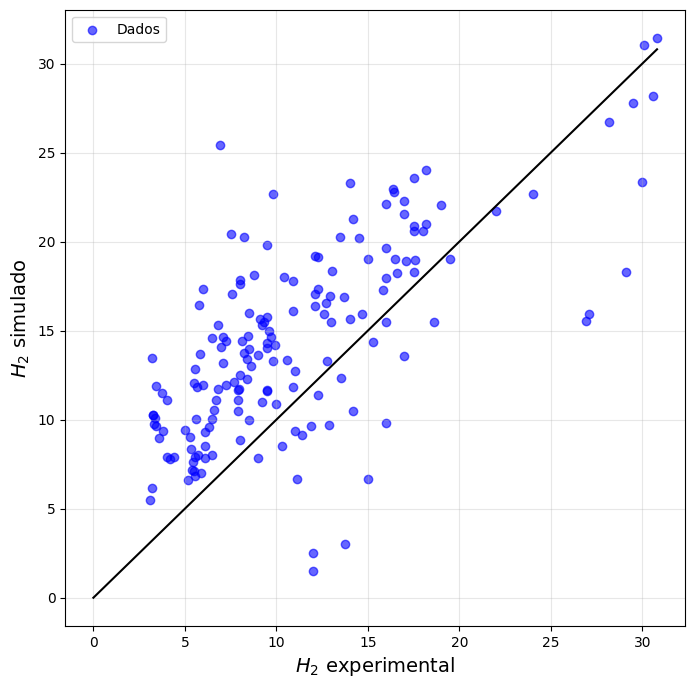

In [36]:
plt.figure(figsize=(8, 8))
plt.scatter(real_values, predicted_values, alpha=0.6, color='blue', label='Dados')
plt.plot([0, max(real_values)], [0, max(real_values)], 
         color='black', linestyle='-')

plt.xlabel('$H_2$ experimental', fontsize=14)
plt.ylabel('$H_2$ simulado', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

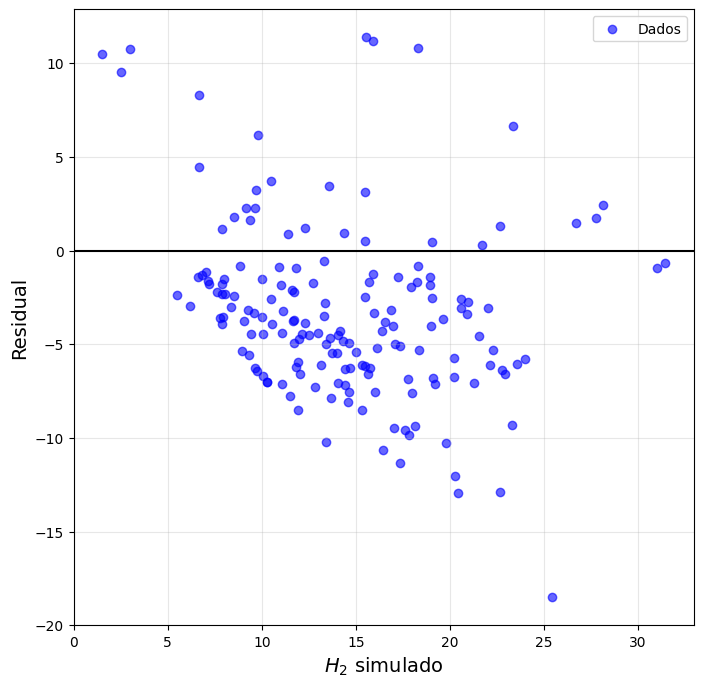

In [37]:
resi = (real_values-predicted_values)
plt.figure(figsize=(8, 8))
plt.scatter(predicted_values, resi, alpha=0.6, color='blue', label='Dados') 
plt.axhline(0, color='black', linestyle='-')

plt.xlabel('$H_2$ simulado', fontsize=14)
plt.ylabel('Residual', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.show()